<a href="https://colab.research.google.com/github/Suresh045/TNSDC/blob/main/nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download NLTK resources (only once)
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Load your WhatsApp chat file
file_path = "/content/WhatsApp Chat with Tamil AI Data Science Community .txt"

with open(file_path, 'r', encoding='utf-8') as f:
    data = f.readlines()

print("Total lines in chat:", len(data))
print("First 10 lines:\n", data[:10])


Total lines in chat: 6061
First 10 lines:
 ['2/26/25, 8:25\u202fPM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.\n', '2/6/25, 11:45\u202fAM - ~\u202fThiru created group "Tamil AI Data Science Community "\n', "2/26/25, 8:25\u202fPM - You joined using this group's invite link\n", '2/26/25, 8:31\u202fPM - +91 75503 62274: Bro data analytics roadmap sollunga bro\n', '2/26/25, 8:31\u202fPM - +91 63806 54780: Will post bro\n', '2/26/25, 8:38\u202fPM - ~\u202fRegadharani was added\n', '2/26/25, 8:37\u202fPM - +91 63694 76213 joined using a group link.\n', '2/26/25, 9:21\u202fPM - ~\u202fHarish was added\n', '2/26/25, 9:21\u202fPM - +91 88259 44697 joined using a group link.\n', '2/26/25, 9:23\u202fPM - +91 88259 44697: I have some doubt in my ML project..shall I clarify here ?\n']


In [ ]:
chat_data = []
pattern = r"^(\d{1,2}/\d{1,2}/\d{2,4}), (\d{1,2}:\d{2}\s[APM]{2}) - ([^:]+): (.+)"

for line in data:
    match = re.match(pattern, line)
    if match:
        date, time, sender, message = match.groups()
        chat_data.append([date, time, sender, message])

df = pd.DataFrame(chat_data, columns=["Date", "Time", "Sender", "Message"])
df.head()


,Date,Time,Sender,Message
0,2/26/25,8:31 PM,+91 75503 62274,Bro data analytics roadmap sollunga bro
1,2/26/25,8:31 PM,+91 63806 54780,Will post bro
2,2/26/25,9:23 PM,+91 88259 44697,I have some doubt in my ML project..shall I cl...
3,2/26/25,9:26 PM,+91 63806 54780,Yes
4,2/26/25,9:30 PM,+91 88259 44697,OBJECT DETECTION


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()  # Lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words]  # Lemmatization
    return " ".join(words)

df['Cleaned_Message'] = df['Message'].astype(str).apply(preprocess_text)
df[['Message', 'Cleaned_Message']].head(10)


,Message,Cleaned_Message
0,Bro data analytics roadmap sollunga bro,bro data analytics roadmap sollunga bro
1,Will post bro,post bro
2,I have some doubt in my ML project..shall I cl...,doubt ml projectshall clarify
3,Yes,yes
4,OBJECT DETECTION,object detection
5,Are you navigated the anaconda prompt to your ...,navigated anaconda prompt project folder opene...
6,Do this: open anaconda prompt then type cd you...,open anaconda prompt type cd yourprojectfolder...
7,Now it will visible in jupyter notebook,visible jupyter notebook
8,Sure bro..after a try I’ll update you..thanks bro,sure broafter try i’ll update youthanks bro
9,"Suppose, if that not worked copy your all file...",suppose worked copy file folder put folder ana...


In [ ]:
print("Total messages:", df.shape[0])
print("Unique participants:", df['Sender'].nunique())
print("Top senders:\n", df['Sender'].value_counts().head(10))


Total messages: 3283
Unique participants: 351
Top senders:
 Sender
+91 63806 66315    243
+91 94442 99677    189
+91 63806 54780    171
+91 97878 55817    146
+91 98420 83220    114
+91 77690 43307     83
+91 93843 11120     61
+91 86187 44060     56
+91 63812 52307     53
+91 97897 04212     49
Name: count, dtype: int64


/tmp/ipython-input-1124645308.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


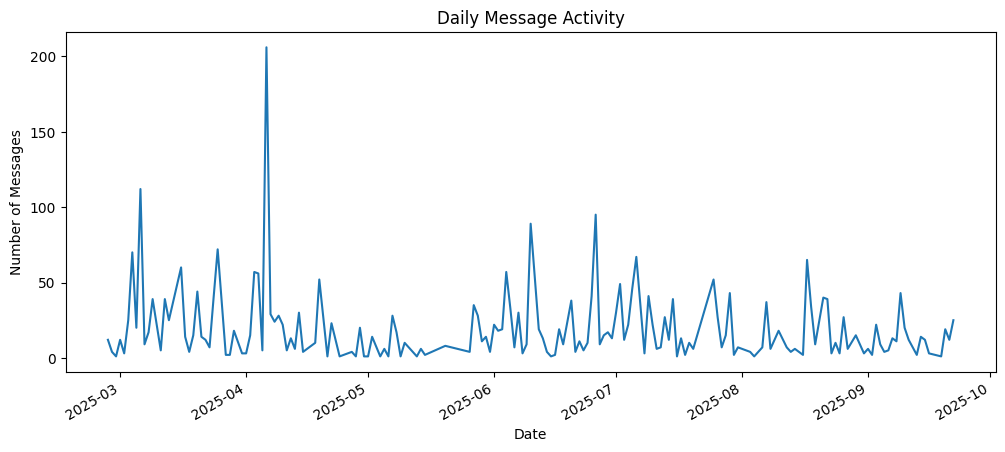

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
daily_activity = df.groupby('Date').size()

plt.figure(figsize=(12,5))
daily_activity.plot()
plt.title("Daily Message Activity")
plt.xlabel("Date")
plt.ylabel("Number of Messages")
plt.show()


[('bro', 606), ('medium', 229), ('omitted', 229), ('ai', 217), ('use', 184), ('message', 165), ('data', 163), ('la', 128), ('project', 124), ('model', 111), ('guy', 109), ('anyone', 105), ('learning', 101), ('ok', 97), ('learn', 91), ('ml', 89), ('need', 88), ('deleted', 87), ('like', 85), ('one', 82)]


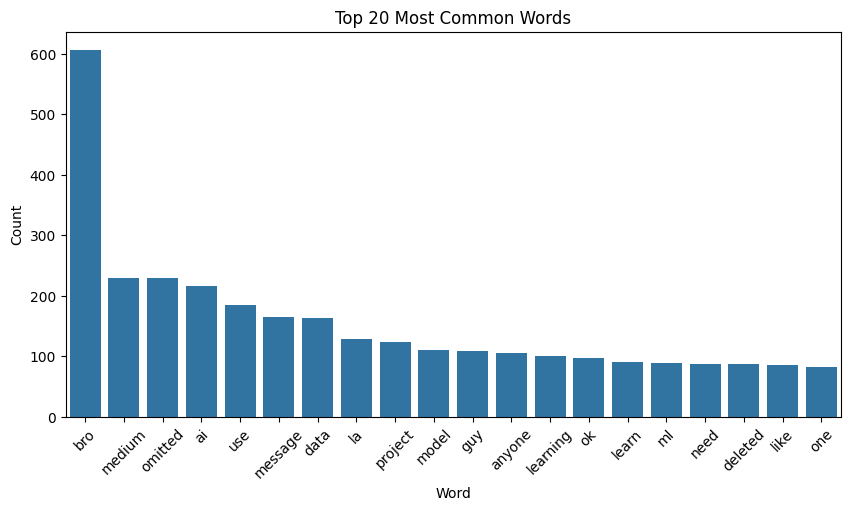

In [ ]:
all_words = " ".join(df['Cleaned_Message'])
words = re.findall(r'\b\w+\b', all_words)

common_words = Counter(words).most_common(20)
print(common_words)

word_df = pd.DataFrame(common_words, columns=['Word', 'Count'])
plt.figure(figsize=(10,5))
sns.barplot(x="Word", y="Count", data=word_df)
plt.title("Top 20 Most Common Words")
plt.xticks(rotation=45)
plt.show()


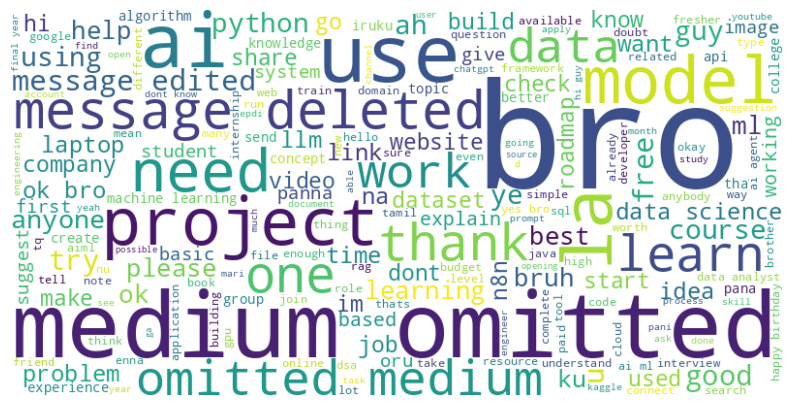

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
!pip install textblob vaderSentiment
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [ ]:
# TextBlob Polarity
df['Polarity'] = df['Cleaned_Message'].apply(lambda x: TextBlob(x).sentiment.polarity)

# VADER Sentiment
analyzer = SentimentIntensityAnalyzer()
df['Sentiment'] = df['Cleaned_Message'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

def categorize_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment_Label'] = df['Sentiment'].apply(categorize_sentiment)
df[['Sender', 'Cleaned_Message', 'Polarity', 'Sentiment', 'Sentiment_Label']].head(10)


,Sender,Cleaned_Message,Polarity,Sentiment,Sentiment_Label
0,+91 75503 62274,bro data analytics roadmap sollunga bro,0.0,0.0000,Neutral
1,+91 63806 54780,post bro,0.0,0.0000,Neutral
2,+91 88259 44697,doubt ml projectshall clarify,0.0,-0.3612,Negative
3,+91 63806 54780,yes,0.0,0.4019,Positive
4,+91 88259 44697,object detection,0.0,0.0000,Neutral
5,+91 63806 54780,navigated anaconda prompt project folder opene...,0.0,0.0000,Neutral
6,+91 63806 54780,open anaconda prompt type cd yourprojectfolder...,0.0,0.0000,Neutral
7,+91 63806 54780,visible jupyter notebook,0.0,0.0000,Neutral
8,+91 88259 44697,sure broafter try i’ll update youthanks bro,0.5,0.3182,Positive
9,+91 63853 29944,suppose worked copy file folder put folder ana...,0.0,0.2732,Positive


/tmp/ipython-input-682283779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_Label', data=df, palette="Set2")


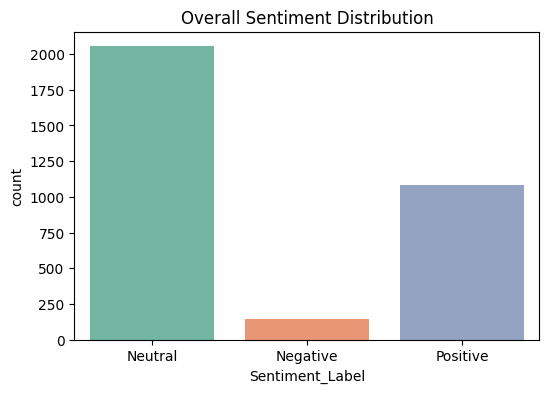

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment_Label', data=df, palette="Set2")
plt.title("Overall Sentiment Distribution")
plt.show()

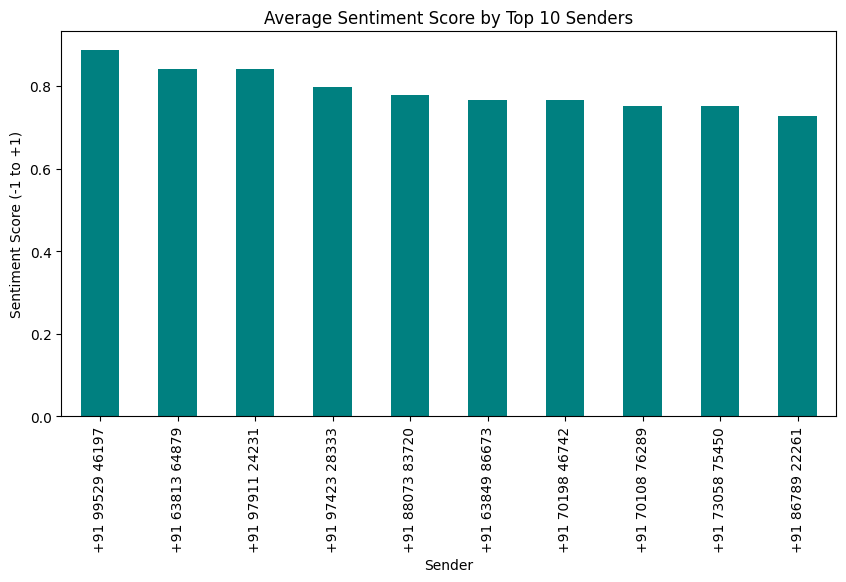

In [ ]:
sentiment_by_user = df.groupby('Sender')['Sentiment'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sentiment_by_user.plot(kind='bar', color='teal')
plt.title("Average Sentiment Score by Top 10 Senders")
plt.ylabel("Sentiment Score (-1 to +1)")
plt.show()
